In [42]:
ccaa_name_map = {
    "ANDALUCIA": "Andalucía",
    "ARAGON": "Aragón",
    "ASTURIAS": "Principado de Asturias",
    "BALEARES": "Illes Balears",
    "CANARIAS": "Canarias",
    "CANTABRIA": "Cantabria",
    "CASTILLA Y LEON": "Castilla y León",
    "CASTILLA-LA MANCHA": "Castilla-La Mancha",
    "CATALUNA": "Cataluña/Catalunya",
    "CEUTA": "Ciudad Autónoma de Ceuta",
    "MELILLA": "Ciudad Autónoma de Melilla",
    "EXTREMADURA": "Extremadura",
    "GALICIA": "Galicia",
    "MADRID": "Comunidad de Madrid",
    "MURCIA": "Región de Murcia",
    "NAVARRA": "Comunidad Foral de Navarra",
    "PAIS VASCO": "País Vasco/Euskadi",
    "LA RIOJA": "La Rioja",
    "VALENCIA": "Comunitat Valenciana"
}

provincia_name_map = {
    "A CORUÑA": "A Coruña",
    "ALBACETE": "Albacete",
    "ALICANTE": "Alacant/Alicante",
    "ALMERIA": "Almería",
    "ARABA/ALAVA": "Araba/Álava",
    "ASTURIAS": "Asturias",
    "AVILA": "Ávila",
    "BADAJOZ": "Badajoz",
    "BALEARES": "Illes Balears",
    "BARCELONA": "Barcelona",
    "BIZKAIA": "Bizkaia",
    "BURGOS": "Burgos",
    "CACERES": "Cáceres",
    "CADIZ": "Cádiz",
    "CANTABRIA": "Cantabria",
    "CASTELLON": "Castelló/Castellón",
    "CEUTA": "Ceuta",
    "CIUDAD REAL": "Ciudad Real",
    "CORDOBA": "Córdoba",
    "CUENCA": "Cuenca",
    "GIPUZKOA": "Gipuzkoa",
    "GIRONA": "Girona",
    "GRANADA": "Granada",
    "GUADALAJARA": "Guadalajara",
    "HUELVA": "Huelva",
    "HUESCA": "Huesca",
    "ILLES BALEARS": "Illes Balears",
    "JAEN": "Jaén",
    "LA RIOJA": "La Rioja",
    "LAS PALMAS": "Las Palmas",
    "LEON": "León",
    "LLEIDA": "Lleida",
    "LUGO": "Lugo",
    "MADRID": "Madrid",
    "MALAGA": "Málaga",
    "MELILLA": "Melilla",
    "MURCIA": "Murcia",
    "NAVARRA": "Navarra",
    "OURENSE": "Ourense",
    "PALENCIA": "Palencia",
    "PONTEVEDRA": "Pontevedra",
    "SALAMANCA": "Salamanca",
    "SANTA CRUZ DE TENERIFE": "Santa Cruz de Tenerife",
    "SEGOVIA": "Segovia",
    "SEVILLA": "Sevilla",
    "SORIA": "Soria",
    "STA. CRUZ DE TENERIFE": "Santa Cruz de Tenerife",
    "TARRAGONA": "Tarragona",
    "TERUEL": "Teruel",
    "TOLEDO": "Toledo",
    "VALENCIA": "València/Valencia",
    "VALLADOLID": "Valladolid",
    "ZAMORA": "Zamora",
    "ZARAGOZA": "Zaragoza"
}


import polars as pl
import altair as alt
import matplotlib.pyplot as plt
import geopandas as gpd

alt.data_transformers.enable("vegafusion")
plt.style.use('seaborn-v0_8-whitegrid')

df = pl.read_parquet("../data/processed/aemet_clean.parquet")
df_pd = df.to_pandas()


In [43]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]


### 1.1. Mapa de calor — Temperatura media: provincia × mes

**Tipo:** Mapa de calor (heatmap)
**Datos:** Temperatura promedio por provincia y mes


In [44]:
heatmap_data = (df
    .group_by(["provincia", "mes"])
    .agg(pl.col("temperatura_media").mean().alias("temp_mean"))
    .with_columns(pl.col("mes").cast(pl.Enum(month_order)))
    .sort("mes")
    .to_pandas()
)

alt.Chart(heatmap_data).mark_rect().encode(
    x=alt.X("mes:N", title="Month", sort=list(month_order)),
    y=alt.Y("provincia:N", title="Province"),
    color=alt.Color("temp_mean:Q", title="Avg Temp (C)",
                    scale=alt.Scale(scheme="redyellowblue", reverse=True)),
    tooltip=["provincia", "mes", alt.Tooltip("temp_mean", format=".1f")]
).properties(
    title="Average Temperature: Province x Month",
    width=600,
    height=600
).interactive().show()


<Figure size 1200x800 with 3 Axes>

### 1.2. Mapa de calor — Precipitación media: provincia × mes

**Tipo:** Mapa de calor (heatmap)
**Datos:** Precipitación promedio por provincia y mes


In [45]:
heatmap_precip_mean = (df
    .group_by(["provincia", "mes"])
    .agg(pl.col("precipitacion").mean().alias("precip_mean"))
    .with_columns(pl.col("mes").cast(pl.Enum(month_order)))
    .sort("mes")
    .to_pandas()
)

alt.Chart(heatmap_precip_mean).mark_rect().encode(
    x=alt.X("mes:N", title="Month", sort=list(month_order)),
    y=alt.Y("provincia:N", title="Province"),
    color=alt.Color("precip_mean:Q", title="Avg Precipitation (mm)",
                    scale=alt.Scale(scheme="blues", reverse=True)),
    tooltip=["provincia", "mes", alt.Tooltip("precip_mean", format=".1f")]
).properties(
    title="Average Precipitation: Province x Month",
    width=600,
    height=600
).interactive().show()


alt.Chart(...)

### 1.3. Mapa de calor — Velocidad del viento media: provincia × mes

**Tipo:** Mapa de calor (heatmap)
**Datos:** Velocidad del viento promedio por provincia y mes


In [46]:
heatmap_viento_mean = (df
    .group_by(["provincia", "mes"])
    .agg(pl.col("velocidad_viento_media").mean().alias("viento_mean"))
    .with_columns(pl.col("mes").cast(pl.Enum(month_order)))
    .sort("mes")
    .to_pandas()
)

alt.Chart(heatmap_viento_mean).mark_rect().encode(
    x=alt.X("mes:N", title="Month", sort=list(month_order)),
    y=alt.Y("provincia:N", title="Province"),
    color=alt.Color("viento_mean:Q", title="Avg Wind Speed (m/s)",
                    scale=alt.Scale(scheme="greens", reverse=True)),
    tooltip=["provincia", "mes", alt.Tooltip("viento_mean", format=".1f")]
).properties(
    title="Average Wind Speed: Province x Month",
    width=600,
    height=600
).interactive().show()


alt.Chart(...)

### 1.4. Diagrama de dispersión — Temperatura vs Precipitación

**Tipo:** Scatter plot con selector interactivo por provincia
**Datos:** Relación temperatura/precipitación. Selecciona una provincia. Color = mes. Cada punto = un mes.


In [47]:
scatter_precip = (df
    .group_by(["mes", "provincia"])
    .agg([
        pl.col("temperatura_media").mean().alias("temp_mean"),
        pl.col("precipitacion").mean().alias("precip_mean"),
    ])
    .with_columns(pl.col("mes").cast(pl.Enum(month_order)))
    .sort("mes")
    .to_pandas()
)


In [ ]:
prov_list_precip = sorted(scatter_precip["provincia"].unique())

selector_precip = alt.selection_point(
    fields=["provincia"],
    bind=alt.binding_select(options=prov_list_precip, name="Select Province: "),
    value=[{"provincia": prov_list_precip[0]}]
)

alt.Chart(scatter_precip).mark_circle(size=60, opacity=0.7).encode(
    x=alt.X("temp_mean:Q", title="Avg Temperature (C)"),
    y=alt.Y("precip_mean:Q", title="Avg Precipitation (mm)"),
    color=alt.Color("mes:N", title="Month", sort=list(month_order),
                    scale=alt.Scale(scheme="turbo")),
    tooltip=["mes", "provincia",
             alt.Tooltip("temp_mean", format=".1f"),
             alt.Tooltip("precip_mean", format=".2f")]
).add_params(
    selector_precip
).transform_filter(
    selector_precip
).properties(
    title="Temperature vs Precipitation by Province & Month",
    width=600,
    height=400
).interactive().show()


alt.Chart(...)

### 1.5. Diagrama de dispersión — Temperatura vs Velocidad del viento

**Tipo:** Scatter plot con selector interactivo por provincia
**Datos:** Relación temperatura/viento. Selecciona una provincia. Color = mes. Cada punto = un mes.


In [ ]:
scatter_viento = (df
    .group_by(["mes", "provincia"])
    .agg([
        pl.col("temperatura_media").mean().alias("temp_mean"),
        pl.col("velocidad_viento_media").mean().alias("viento_mean"),
    ])
    .with_columns(pl.col("mes").cast(pl.Enum(month_order)))
    .sort("mes")
    .to_pandas()
)


In [ ]:
prov_list_viento = sorted(scatter_viento["provincia"].unique())

selector_viento = alt.selection_point(
    fields=["provincia"],
    bind=alt.binding_select(options=prov_list_viento, name="Select Province: "),
    value=[{"provincia": prov_list_viento[0]}]
)

alt.Chart(scatter_viento).mark_circle(size=60, opacity=0.7).encode(
    x=alt.X("temp_mean:Q", title="Avg Temperature (C)"),
    y=alt.Y("viento_mean:Q", title="Avg Wind Speed (m/s)"),
    color=alt.Color("mes:N", title="Month", sort=list(month_order),
                    scale=alt.Scale(scheme="turbo")),
    tooltip=["mes", "provincia",
             alt.Tooltip("temp_mean", format=".1f"),
             alt.Tooltip("viento_mean", format=".2f")]
).add_selection(
    selector_viento
).transform_filter(
    selector_viento
).properties(
    title="Temperature vs Wind Speed by Province & Month",
    width=600,
    height=400
).interactive().show()


C:\Users\vgtra\AppData\Local\Temp\ipykernel_19536\2535353380.py:17: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  ).add_selection(


alt.Chart(...)

### 1.6. Mapa de calor — Correlaciones entre variables numéricas

**Tipo:** Mapa de calor (heatmap) de correlaciones
**Datos:** Matriz de correlación entre todas las variables numéricas del dataset AEMET


In [ ]:
num_cols = [
    "temperatura_media", "precipitacion", "temperatura_minima",
    "temperatura_maxima", "humedad_relativa_media", "humedad_relativa_maxima",
    "humedad_relativa_minima", "velocidad_viento_media", "racha_maxima_viento"
]

corr_df = df.select(num_cols).to_pandas().corr().reset_index()
corr_melted = corr_df.melt(id_vars="index", var_name="var2", value_name="corr")
corr_melted.columns = ["var1", "var2", "corr"]

alt.Chart(corr_melted).mark_rect().encode(
    x=alt.X("var1:N", title=""),
    y=alt.Y("var2:N", title=""),
    color=alt.Color("corr:Q", title="Correlation",
                    scale=alt.Scale(scheme="redblue", domain=[-1, 1], reverse=True)),
    tooltip=["var1", "var2", alt.Tooltip("corr", format=".2f")]
).properties(
    title="Correlation Heatmap (Numeric Variables)",
    width=500,
    height=500
).interactive().show()

alt.Chart(...)

### 1.7. Mapas coropléticos de España por provincia

**Tipo:** Mapas coropléticos (choropleth)
**Datos:** Temperatura, precipitación y velocidad del viento promedio por provincia


c:\Users\vgtra\Desktop\proyecto4-grupo3\.venv\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'provinces.json': 'provinces' (default), 'autonomous_regions', 'border'. Specify layer parameter to avoid this warning.
  result = read_func(


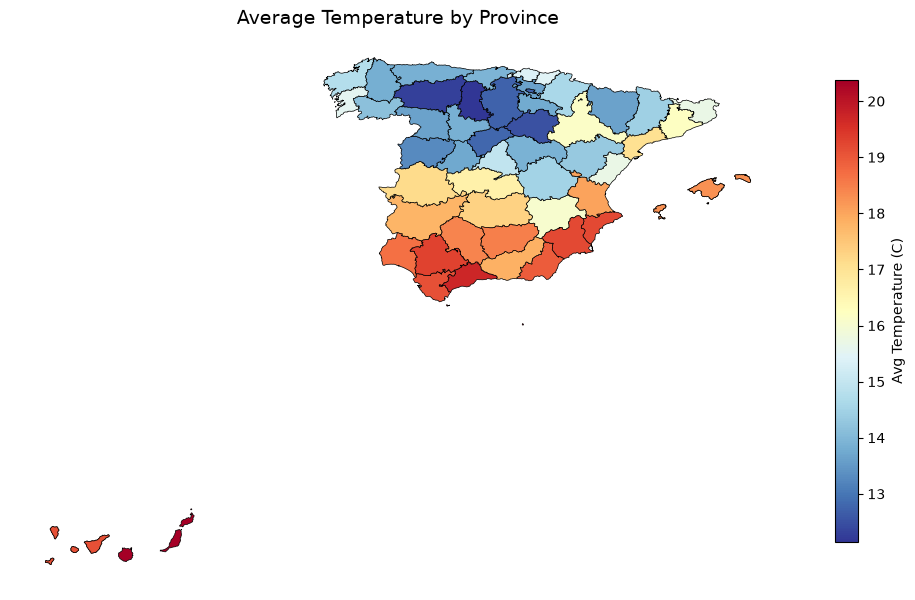

In [ ]:
# Mapa de temp mean con matplotlib + geopandas
url = "https://unpkg.com/es-atlas/es/provinces.json"
gdf = gpd.read_file(url)

prov_map = (df
    .group_by("provincia")
    .agg(pl.col("temperatura_media").mean().alias("temp_mean"))
    .with_columns(pl.col("provincia").replace_strict(provincia_name_map).alias("name"))
    .to_pandas()
)

gdf = gdf.merge(prov_map, on="name", how="left")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf.plot(column="temp_mean", ax=ax, legend=True,
         cmap="RdYlBu_r", edgecolor="black", linewidth=0.5,
         legend_kwds={"label": "Avg Temperature (C)", "shrink": 0.6})
ax.set_title("Average Temperature by Province", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()


c:\Users\vgtra\Desktop\proyecto4-grupo3\.venv\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'provinces.json': 'provinces' (default), 'autonomous_regions', 'border'. Specify layer parameter to avoid this warning.
  result = read_func(


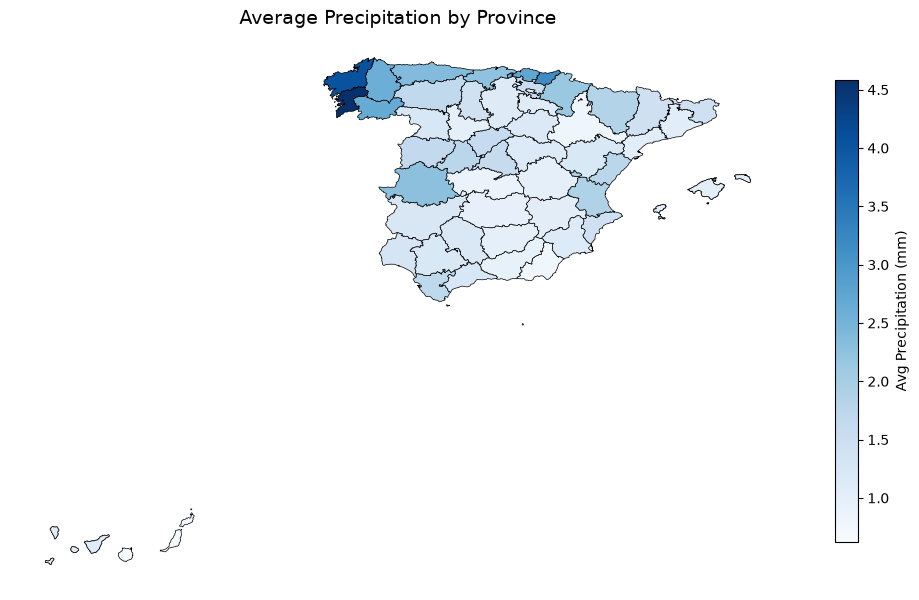

In [ ]:
# Mapa de precip mean con matplotlib + geopandas
url = "https://unpkg.com/es-atlas/es/provinces.json"
gdf = gpd.read_file(url)

prov_map = (df
    .group_by("provincia")
    .agg(pl.col("precipitacion").mean().alias("precip_mean"))
    .with_columns(pl.col("provincia").replace_strict(provincia_name_map).alias("name"))
    .to_pandas()
)

gdf = gdf.merge(prov_map, on="name", how="left")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf.plot(column="precip_mean", ax=ax, legend=True,
         cmap="Blues", edgecolor="black", linewidth=0.5,
         legend_kwds={"label": "Avg Precipitation (mm)", "shrink": 0.6})
ax.set_title("Average Precipitation by Province", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()


c:\Users\vgtra\Desktop\proyecto4-grupo3\.venv\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'provinces.json': 'provinces' (default), 'autonomous_regions', 'border'. Specify layer parameter to avoid this warning.
  result = read_func(


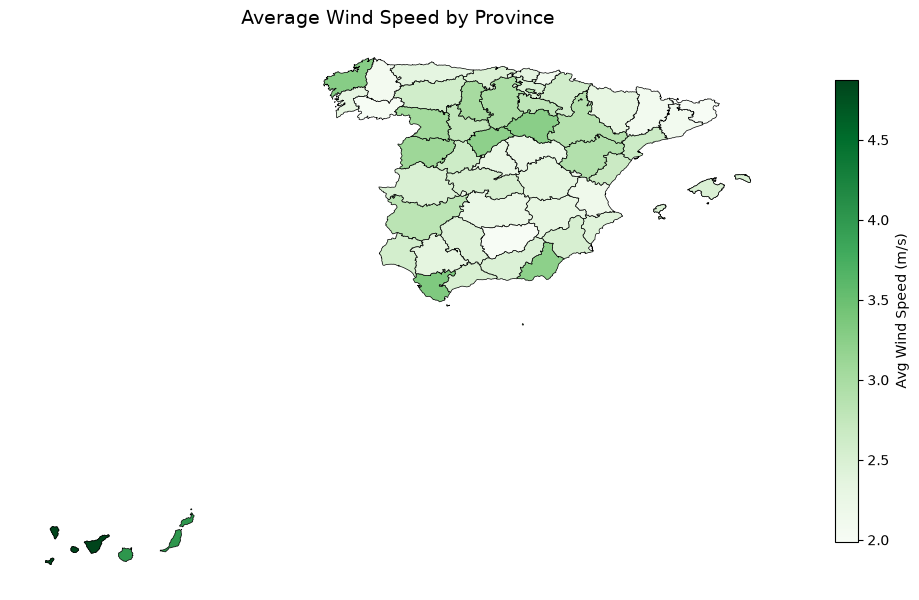

In [ ]:
# Mapa de viento mean con matplotlib + geopandas
url = "https://unpkg.com/es-atlas/es/provinces.json"
gdf = gpd.read_file(url)

prov_map = (df
    .group_by("provincia")
    .agg(pl.col("velocidad_viento_media").mean().alias("viento_mean"))
    .with_columns(pl.col("provincia").replace_strict(provincia_name_map).alias("name"))
    .to_pandas()
)

gdf = gdf.merge(prov_map, on="name", how="left")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf.plot(column="viento_mean", ax=ax, legend=True,
         cmap="Greens", edgecolor="black", linewidth=0.5,
         legend_kwds={"label": "Avg Wind Speed (m/s)", "shrink": 0.6})
ax.set_title("Average Wind Speed by Province", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()
